In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold,cross_val_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
import joblib

In [2]:
def processing_mat_file(file_name,is_recovery):

    raw_data = loadmat(file_name)
    t = raw_data["t"].squeeze()
    df = raw_data["df"].squeeze()
    df_set = pd.DataFrame({"Time": t, "Frequency_Change": df})
    dt = df_set["Time"].diff().mean()
    df_set["RoCoF"] = df_set["Frequency_Change"].diff() / dt
    df_set["Frequency_Accleration"] = df_set["RoCoF"].diff() / dt
    df_set["df_RollingMean"] = df_set["Frequency_Change"].ewm(span=20,
                                                                  adjust=False).mean()
    df_set["Cumulative_Drop"] = df_set["Frequency_Change"].ewm(span = 50,
                                                    adjust = False).mean() * dt * 50
    df_set["RoCoF_Variance"] = df_set["RoCoF"].ewm(span = 5,adjust = False).var().fillna(0)
    df_set["RoCoF_Elasticity"] = df_set["Frequency_Accleration"]/df_set["RoCoF"]
    df_set["RoCoF_Elasticity"] = df_set["RoCoF_Elasticity"].replace([np.inf, -np.inf], 0).fillna(0)

    if is_recovery:
        df_set["Collaspe_Risk"] = 0

    else:
        threshold = df_set[df_set["Frequency_Change"] <= -0.05]["Time"].min()
        df_set["Collaspe_Risk"] = (df_set["Time"]>=threshold).astype(int)

    FORECAST_STEPS = 100
    df_set["Future_Collaspe_Risk"] = df_set["Collaspe_Risk"].shift(-FORECAST_STEPS)
    return df_set.dropna()


In [3]:
def Training_function(model,x,y,groups):

    x_train,y_train= x,y
    
    model_name = model.fit(x_train,y_train)

    gkf = GroupKFold(n_splits=4)
    cv_score = cross_val_score(model,x_train,y_train,
                scoring = "accuracy",cv = gkf,groups = groups)
    cv_score = np.abs(np.mean(cv_score))

    print("--- MODEL REPORT ----")
    print("MODEL TYPE :",model)
    print("CV SCORE :",cv_score)
    
    fig,axs = plt.subplots(figsize  = (10,5))

    importances = pd.Series(model.feature_importances_, 
                    index=x.columns).sort_values(ascending=False)
    importances.plot(kind='bar', ax=axs, color='teal')
    axs.set_title("Feature Importance ")
    axs.grid(axis='y', linestyle='--', alpha=0.7)
    axs.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    
    return model_name

In [4]:
def Testing_Function(file_name, is_recovery):

    features = ["Frequency_Change", "RoCoF", "Frequency_Accleration",
                "df_RollingMean", "Cumulative_Drop","RoCoF_Variance",
                "RoCoF_Elasticity"]

    raw_test_data = loadmat(file_name)
    t_test = raw_test_data["t"].squeeze()
    df_test = raw_test_data["df"].squeeze()

    test_df = pd.DataFrame({
        "Time": t_test,
        "Frequency_Change": df_test
    })

    dt_test = test_df["Time"].diff().mean()
    
    test_df["RoCoF"] = test_df["Frequency_Change"].diff() / dt_test
    test_df["Frequency_Accleration"] = test_df["RoCoF"].diff() / dt_test
    test_df["df_RollingMean"] = test_df["Frequency_Change"].ewm(span=20, adjust = False).mean()
    test_df["Cumulative_Drop"] = test_df["Frequency_Change"].ewm(span=50, adjust = False).mean() * dt_test * 50
    test_df["RoCoF_Variance"] = test_df["RoCoF"].ewm(span = 5,adjust=False).var().fillna(0)
    test_df["RoCoF_Elasticity"] = test_df["Frequency_Accleration"]/test_df["RoCoF"]
    test_df["RoCoF_Elasticity"] = test_df["RoCoF_Elasticity"].replace([np.inf, -np.inf], 0).fillna(0)

    if is_recovery:
        test_df["Collaspe_Risk"] = 0
    else:
        threshold = test_df[test_df["Frequency_Change"] <= -0.05]["Time"].min()
        test_df["Collaspe_Risk"] = (test_df["Time"] >= threshold).astype(int)

    FORECAST_STEPS = 100
    test_df["Future_Collaspe_Risk"] = test_df["Collaspe_Risk"].shift(-FORECAST_STEPS)

    test_df = test_df.dropna().reset_index(drop=True)

    x_test = test_df[features]
    y_test = test_df["Future_Collaspe_Risk"]

    model_prediction = GridMind_AI.predict(x_test)

    fig, axs = plt.subplots(figsize=[10, 3])
    cm_test = confusion_matrix(y_test, model_prediction, labels=[0, 1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                       display_labels=["Safe Grid (0)", "Collapse Risk (1)"])
    disp_test.plot(cmap="Blues", ax=axs)
    plt.title("CONFUSION MATRIX: REALITY VS PREDICTION")
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, model_prediction))

    plt.figure(figsize = [10,5])
    plt.subplot(2, 1, 1)
    plt.plot(test_df["Time"], test_df["Frequency_Change"], color="black", label="Frequency Drop (df)")
    
    if not is_recovery:
        plt.axvline(x=threshold, color="red", linestyle="--", label=f"Threshold {threshold:.2f} sec")

    plt.ylabel("Frequency Change ")
    plt.title("Grid Timeline")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(test_df["Time"], y_test, label="Ground Truth", color="green", alpha=0.6, linewidth=3)
    plt.plot(test_df["Time"], model_prediction, label="AI Prediction", color="blue", linestyle=":")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Alarm State")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

---
MODEL TRAINING : 

In [5]:
crash_1 = processing_mat_file("crash_1.mat",is_recovery=False)
crash_2 = processing_mat_file("crash_2.mat",is_recovery=False)
recovery_1 = processing_mat_file("recovery_1.mat",is_recovery=True)
recovery_2 = processing_mat_file("recovery_2.mat",is_recovery=True)

crash_1["Group"] = 1
crash_2["Group"] = 2
recovery_1["Group"] = 3
recovery_2["Group"] = 4

data_frame = pd.DataFrame()
data_frame = pd.concat([crash_1,crash_2,recovery_1,recovery_2],
                       axis = 0).reset_index(drop = True)

--- MODEL REPORT ----
MODEL TYPE : RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=20, random_state=42)
CV SCORE : 0.9275612280096586


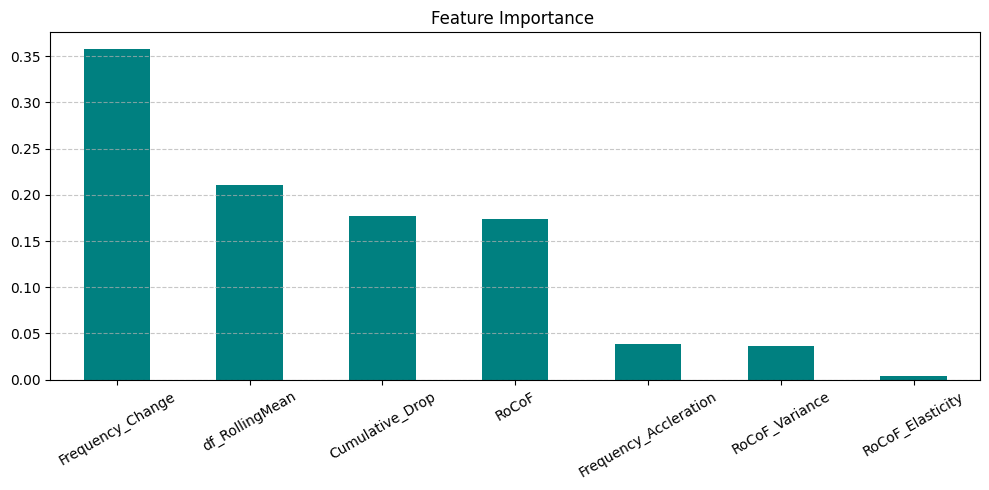

In [6]:
features = ["Frequency_Change", "RoCoF", "Frequency_Accleration",
                "df_RollingMean", "Cumulative_Drop","RoCoF_Variance",
                "RoCoF_Elasticity"]

x = data_frame[features]
y = data_frame["Future_Collaspe_Risk"]
groups = data_frame["Group"]

model = RandomForestClassifier(
                                n_estimators=100,
                                max_depth=5,
                                min_samples_split=20,
                               class_weight="balanced",
                               random_state=42)

GridMind_AI = Training_function(model,x,y,groups)

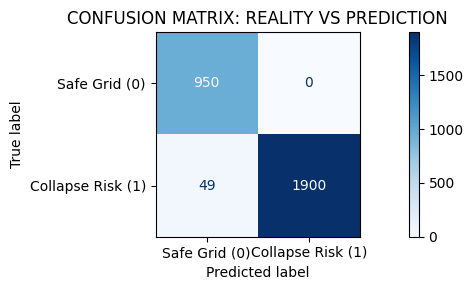

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       950
         1.0       1.00      0.97      0.99      1949

    accuracy                           0.98      2899
   macro avg       0.98      0.99      0.98      2899
weighted avg       0.98      0.98      0.98      2899



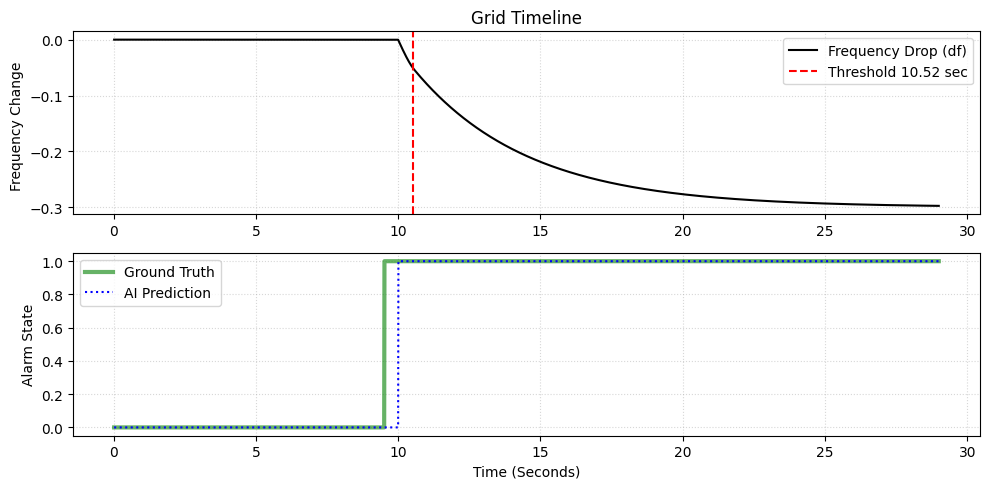

In [7]:
Testing_Function("crash_test_1.mat",is_recovery=False)

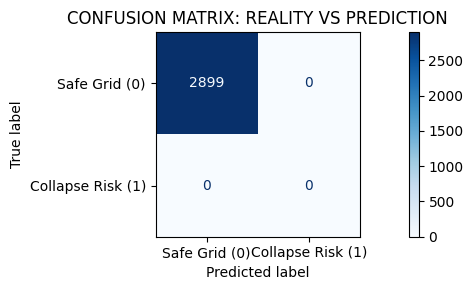

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2899

    accuracy                           1.00      2899
   macro avg       1.00      1.00      1.00      2899
weighted avg       1.00      1.00      1.00      2899



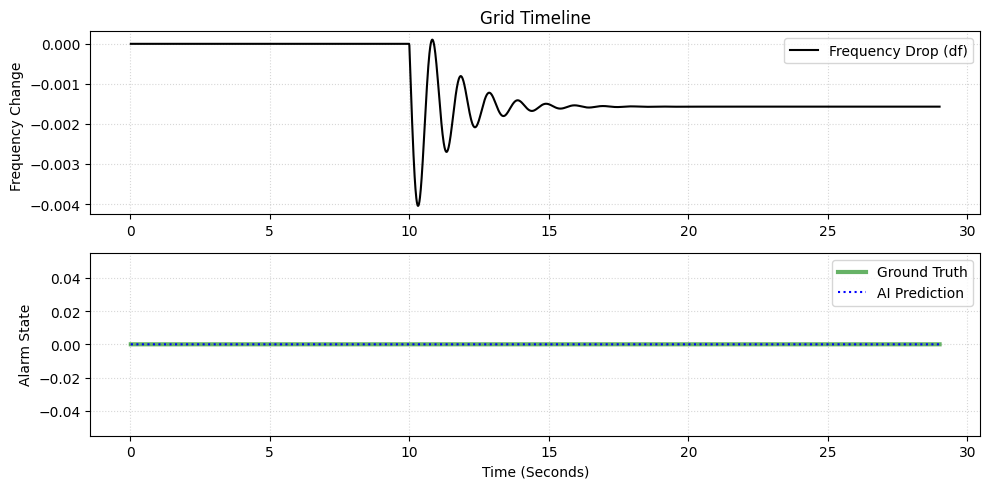

In [8]:
Testing_Function("recovery_test_1.mat",is_recovery=True)

In [9]:
joblib.dump(GridMind_AI,"GridMind_AI.pkl")

['GridMind_AI.pkl']